#Imports

In [2]:
from PIL import Image
import os
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import optimizers
from tensorflow.keras import models
from tensorflow.keras import layers



# Obtener Path de google drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
%cd "/content/drive/MyDrive/RecoCubes/"
!ls

/content/drive/MyDrive/RecoCubes
images


# Preprocesamiento de datos

## Validar tamaños

In [5]:
def print_images_size_summary(sizes, clases_info):

  print("="*60)
  print("TAMAÑOS DE IMAGEN EN EL DATASET")
  print("="*60)

  contador = Counter(sizes)
  print(f"\nTotal imágenes analizadas: {len(sizes)}")
  print(f"Cantidad de tamaños diferentes: {len(contador)}")
  print(f"\nDistribución de tamaños:")
  for tamaño, cantidad in contador.most_common():
      print(f"  {tamaño[0]}x{tamaño[1]} píxeles: {cantidad} imágenes")

  print(f"\n{'='*60}")
  print("TAMAÑOS POR CLASE")
  print("="*60)
  for clase, sizes_clase in clases_info.items():
      contador_clase = Counter(sizes_clase)
      if len(contador_clase) == 1:
          size = list(contador_clase.keys())[0]
          print(f"{clase}: TODAS son {size[0]}x{size[1]}")
      else:
          print(f"{clase}: tiene {len(contador_clase)} tamaños diferentes")
          for s, c in contador_clase.items():
              print(f"      {s[0]}x{s[1]}: {c} imágenes")


In [6]:
def get_size_images(base_dir):
  sizes = []
  clases_info = {}

  for clase in os.listdir(base_dir):
      clase_path = os.path.join(base_dir, clase)
      if os.path.isdir(clase_path):
          clase_sizes = []
          for img_name in os.listdir(clase_path):
              img_path = os.path.join(clase_path, img_name)
              try:
                  with Image.open(img_path) as img:
                      sizes.append(img.size)
                      clase_sizes.append(img.size)
              except:
                  pass
          clases_info[clase] = clase_sizes
  print_images_size_summary(sizes, clases_info)


In [7]:
base_dir = 'images/train'
get_size_images(base_dir)

TAMAÑOS DE IMAGEN EN EL DATASET

Total imágenes analizadas: 630
Cantidad de tamaños diferentes: 1

Distribución de tamaños:
  128x128 píxeles: 630 imágenes

TAMAÑOS POR CLASE
diamond_ore: TODAS son 128x128
brick: TODAS son 128x128
glowstone: TODAS son 128x128
netherrack: TODAS son 128x128
iron_ore: TODAS son 128x128
gold_ore: TODAS son 128x128
emerald_block: TODAS son 128x128
planks_oak: TODAS son 128x128
sand: TODAS son 128x128


In [8]:
base_dir = 'images/test'
get_size_images(base_dir)

TAMAÑOS DE IMAGEN EN EL DATASET

Total imágenes analizadas: 135
Cantidad de tamaños diferentes: 1

Distribución de tamaños:
  128x128 píxeles: 135 imágenes

TAMAÑOS POR CLASE
brick: TODAS son 128x128
emerald_block: TODAS son 128x128
diamond_ore: TODAS son 128x128
iron_ore: TODAS son 128x128
glowstone: TODAS son 128x128
gold_ore: TODAS son 128x128
netherrack: TODAS son 128x128
planks_oak: TODAS son 128x128
sand: TODAS son 128x128


In [9]:
base_dir = 'images/validation'
get_size_images(base_dir)

TAMAÑOS DE IMAGEN EN EL DATASET

Total imágenes analizadas: 135
Cantidad de tamaños diferentes: 1

Distribución de tamaños:
  128x128 píxeles: 135 imágenes

TAMAÑOS POR CLASE
diamond_ore: TODAS son 128x128
emerald_block: TODAS son 128x128
brick: TODAS son 128x128
glowstone: TODAS son 128x128
iron_ore: TODAS son 128x128
gold_ore: TODAS son 128x128
sand: TODAS son 128x128
netherrack: TODAS son 128x128
planks_oak: TODAS son 128x128


## Data Augmentation

In [10]:

base_dir = 'images'
train_dir = os.path.join(base_dir,'train')
test_dir = os.path.join(base_dir, 'test')

In [11]:
#Cada que use el objeto las guardes en disco duro
path = "/content/drive/MyDrive/RecoCubes/images"
train_datagen = ImageDataGenerator(
							rescale = 1./255,
							rotation_range = 10,
							width_shift_range = 0.2,
							zoom_range = 0.3,
							horizontal_flip = True)

train_generator = train_datagen.flow_from_directory(
							train_dir,
							target_size = (128, 128),
							batch_size = 9,
							class_mode ='categorical',
							save_to_dir= path + '/augmented',
              save_prefix='aug',
              save_format='png'
							)

Found 630 images belonging to 9 classes.


# Confirmación del Data augmentation

(9, 128, 128, 3)
[[0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0.]]


<Figure size 640x480 with 0 Axes>

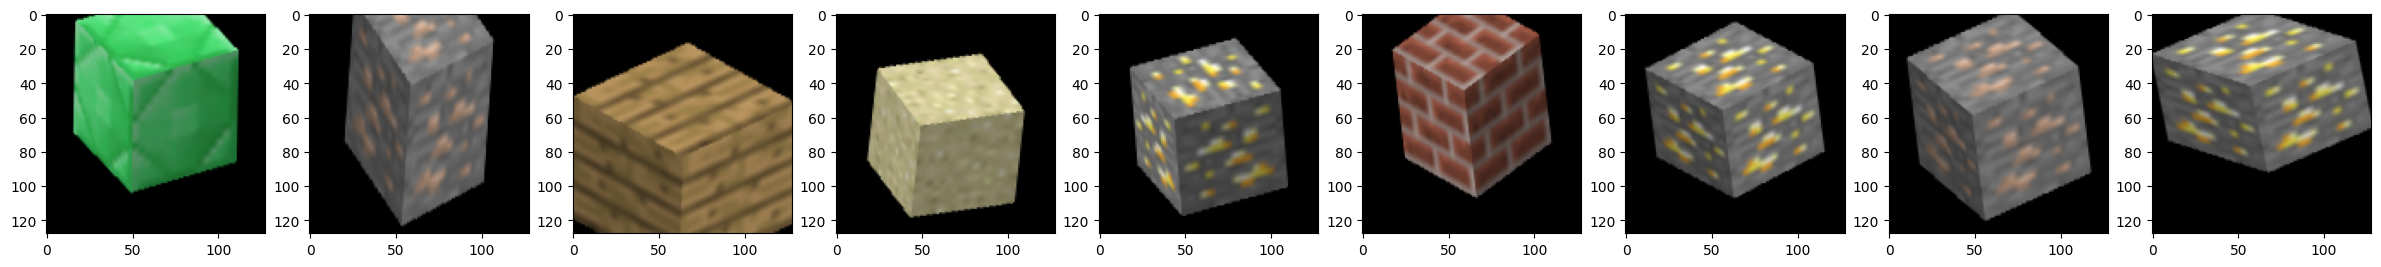

In [12]:
images , labels = train_generator[0]

print(images.shape)
print(labels)


plt.figure()
#subplot(r,c) provide the no. of rows and columns
f, axarr = plt.subplots(1, images.shape[0], figsize=(30, 4))

for i in range(images.shape[0]) :
  axarr[i].imshow(images[i])

Esta es una red neuronal convolutiva:

In [13]:


model = models.Sequential()
model.add(layers.Conv2D(10, (3, 3), activation="relu", input_shape = (128,128,3)))
model.add(layers.Flatten())
model.add(layers.Dense(256,activation='relu'))
model.add(layers.Dense(9,activation='softmax'))

model.summary()

model.compile(loss='categorical_crossentropy',
						optimizer=optimizers.RMSprop(learning_rate=2e-5),
						metrics=['acc'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 158760)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    40,642,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,645,409 (155.05 MB)

 Trainable params: 40,645,409 (155.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/7
70/70 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - acc: 0.2444 - loss: 1.9939
Epoch 2/7
70/70 ━━━━━━━━━━━━━━━━━━━━ 62s 886ms/step - acc: 0.4079 - loss: 1.6089
Epoch 3/7
70/70 ━━━━━━━━━━━━━━━━━━━━ 62s 889ms/step - acc: 0.4810 - loss: 1.4170
Epoch 4/7
70/70 ━━━━━━━━━━━━━━━━━━━━ 62s 890ms/step - acc: 0.5016 - loss: 1.2827
Epoch 5/7
70/70 ━━━━━━━━━━━━━━━━━━━━ 61s 866ms/step - acc: 0.5317 - loss: 1.1907
Epoch 6/7
70/70 ━━━━━━━━━━━━━━━━━━━━ 60s 847ms/step - acc: 0.5556 - loss: 1.1311
Epoch 7/7
70/70 ━━━━━━━━━━━━━━━━━━━━ 62s 879ms/step - acc: 0.5635 - loss: 1.0700


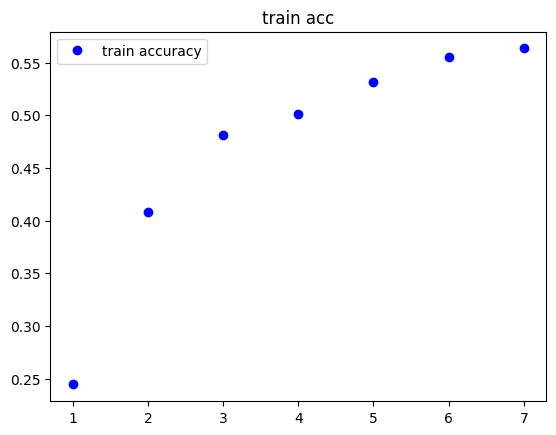

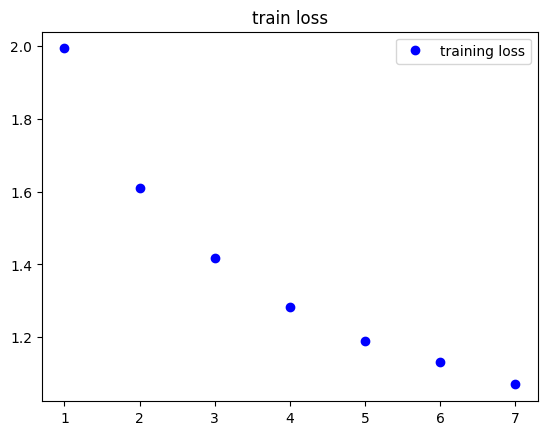

In [14]:
history = model.fit(
						train_generator,
						epochs = 7)


acc = history.history['acc']
loss = history.history['loss']

epochs = range(1, len(acc)+1)

plt.plot(epochs,acc,'bo',label='train accuracy')
plt.title('train acc')
plt.legend()

plt.figure()

plt.plot(epochs,loss, 'bo', label ='training loss')
plt.title('train loss')
plt.legend()

plt.show()

In [15]:
#EN test se usa las imagenes reales
test_datagen = ImageDataGenerator(1./255)
test_generator = test_datagen.flow_from_directory(
					test_dir,
					target_size = (128, 128),
					batch_size = 20,
					class_mode= 'categorical')

test_loss, test_acc = model.evaluate(test_generator, steps = 25)
print('\ntest acc :\n', test_acc)


Found 135 images belonging to 9 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:1261: UserWarning: This ImageDataGenerator specifies `featurewise_center`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn(


25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - acc: 0.6519 - loss: 58.6748 

test acc :
 0.6518518328666687


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
